In [1]:
!pip install tslearn

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

from sklearn.metrics import accuracy_score, f1_score
from tslearn.datasets import UCR_UEA_datasets

In [3]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

print("Seed fixed:", seed)

Seed fixed: 42


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [5]:
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

In [6]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("Unique labels:", np.unique(y_train))
print("Number of classes:", len(np.unique(y_train)))

X_train shape: (2459, 36, 6)
y_train shape: (2459,)
X_test shape: (2466, 36, 6)
y_test shape: (2466,)
Unique labels: ['15' '16' '42' '52' '53' '6' '62' '64' '65' '67' '88' '90' '92' '95']
Number of classes: 14


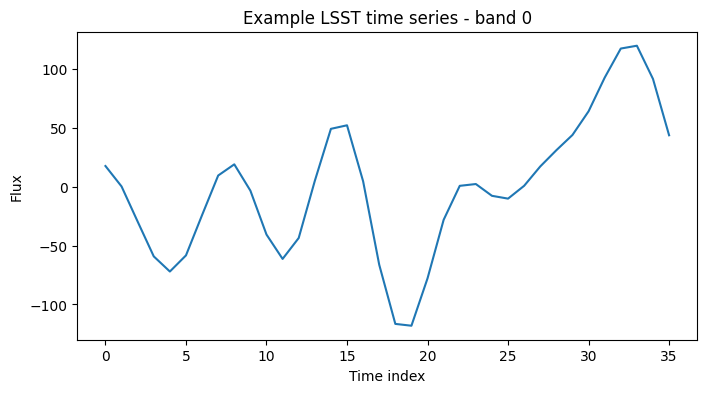

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(X_train[0, :, 0])
plt.title("Example LSST time series - band 0")
plt.xlabel("Time index")
plt.ylabel("Flux")
plt.show()

In [8]:
unique_labels = np.unique(y_train)

label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

y_train = np.array([label_to_idx[y] for y in y_train])
y_test = np.array([label_to_idx[y] for y in y_test])

print("Mapping:", label_to_idx)
print("Mapped labels:", np.unique(y_train))
print("num_classes:", len(unique_labels))

Mapping: {np.str_('15'): 0, np.str_('16'): 1, np.str_('42'): 2, np.str_('52'): 3, np.str_('53'): 4, np.str_('6'): 5, np.str_('62'): 6, np.str_('64'): 7, np.str_('65'): 8, np.str_('67'): 9, np.str_('88'): 10, np.str_('90'): 11, np.str_('92'): 12, np.str_('95'): 13}
Mapped labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
num_classes: 14


In [9]:
mean = X_train.mean()
std = X_train.std()

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("Train mean after normalization:", X_train.mean())
print("Train std after normalization:", X_train.std())

Train mean after normalization: 1.3698653499208173e-17
Train std after normalization: 0.9999999999999998


In [10]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([2459, 36, 6]) torch.Size([2459])
torch.Size([2466, 36, 6]) torch.Size([2466])


In [11]:
full_train_dataset = TensorDataset(X_train, y_train)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

test_dataset = TensorDataset(X_test, y_test)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 1967
Validation size: 492
Test size: 2466


In [12]:
class CNN1DClassifier(nn.Module):
    def __init__(self, input_channels=6, num_classes=14, dropout=0.2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # x: (batch, time, channels)
        x = x.transpose(1, 2)  # -> (batch, channels, time)
        x = self.features(x)
        x = self.classifier(x)
        return x

In [13]:
num_classes = len(unique_labels)

model = CNN1DClassifier(
    input_channels=X_train.shape[2],
    num_classes=num_classes,
    dropout=0.2
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

CNN1DClassifier(
  (features): Sequential(
    (0): Conv1d(6, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.2, inplace=False)
    (2): Linear(in_features=256, out_features=14, bias=True)
  )
)


In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")

    return avg_loss, acc, macro_f1

In [15]:
num_epochs = 20

history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_f1={val_f1:.4f}"
    )

Epoch 01/20 | train_loss=2.2911 | val_loss=2.0884 | val_acc=0.3455 | val_f1=0.0696
Epoch 02/20 | train_loss=1.9218 | val_loss=2.0245 | val_acc=0.3618 | val_f1=0.0961
Epoch 03/20 | train_loss=1.7646 | val_loss=1.7940 | val_acc=0.4167 | val_f1=0.1787
Epoch 04/20 | train_loss=1.6492 | val_loss=1.8222 | val_acc=0.4004 | val_f1=0.1632
Epoch 05/20 | train_loss=1.6303 | val_loss=1.6982 | val_acc=0.4370 | val_f1=0.2045
Epoch 06/20 | train_loss=1.5222 | val_loss=1.7404 | val_acc=0.4146 | val_f1=0.1778
Epoch 07/20 | train_loss=1.4274 | val_loss=2.0606 | val_acc=0.4024 | val_f1=0.1657
Epoch 08/20 | train_loss=1.4187 | val_loss=1.6186 | val_acc=0.4695 | val_f1=0.2765
Epoch 09/20 | train_loss=1.3792 | val_loss=1.6414 | val_acc=0.4593 | val_f1=0.2257
Epoch 10/20 | train_loss=1.3257 | val_loss=1.6154 | val_acc=0.4736 | val_f1=0.2399
Epoch 11/20 | train_loss=1.3275 | val_loss=1.8867 | val_acc=0.4431 | val_f1=0.2623
Epoch 12/20 | train_loss=1.3015 | val_loss=1.6326 | val_acc=0.4878 | val_f1=0.3046
Epoc

In [16]:
test_loss, test_acc, test_f1 = evaluate(model, test_loader, criterion, device)

print("\nFinal test results:")
print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")
print(f"Test macro-F1 : {test_f1:.4f}")


Final test results:
Test loss     : 1.8551
Test accuracy : 0.5097
Test macro-F1 : 0.3207


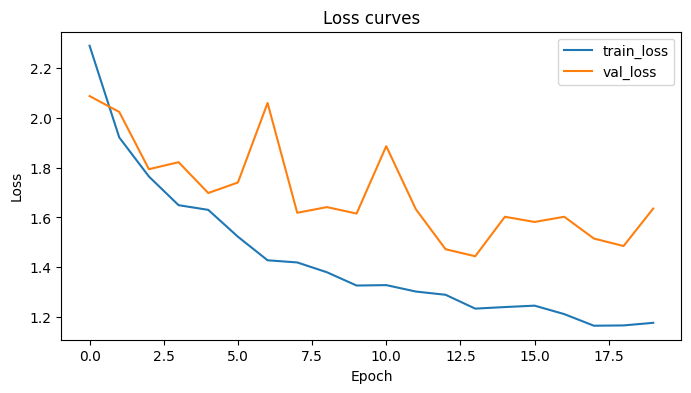

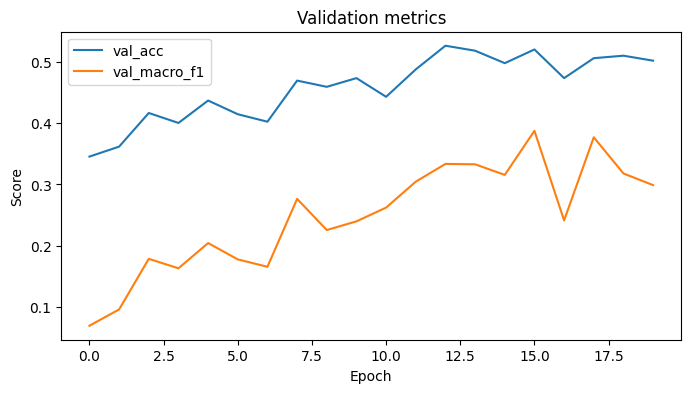

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["val_acc"], label="val_acc")
plt.plot(history["val_f1"], label="val_macro_f1")
plt.legend()
plt.title("Validation metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.show()

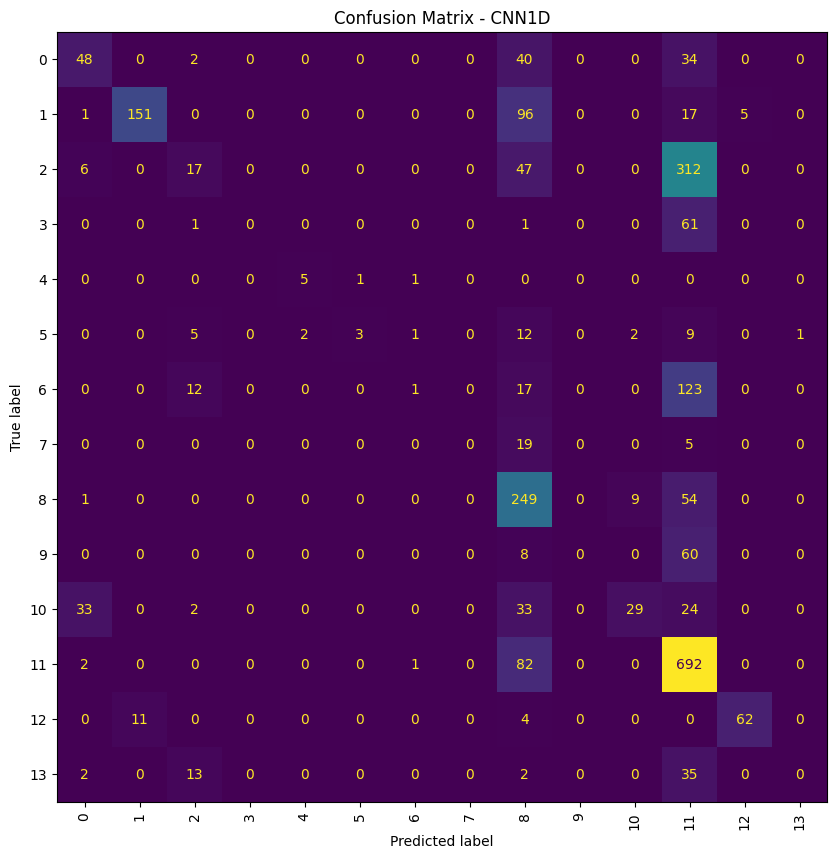

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_targets.extend(yb.numpy())

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Confusion Matrix - CNN1D")
plt.show()